#  UBER NYC DEMAND PREDICTION — PRODUCTION-GRADE PROJECT
#  Dataset: uber-raw-data-apr14.csv
#  Author: k sunandha
#  Objective: Predict hourly ride demand using temporal &
#             spatial features with proper ML methodology
# CELL 1 — Install & Import Libraries
# !pip install folium xgboost lightgbm scikit-learn seaborn pandas numpy matplotlib

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              mean_absolute_percentage_error, r2_score)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import lightgbm as lgb

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("Libraries loaded successfully")

Libraries loaded successfully


Load & Validate Data

In [41]:
df = pd.read_csv("uber-raw-data-apr14.csv")

In [42]:
# Data quality report
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)
print(f"Total records      : {len(df):,}")
print(f"Columns            : {list(df.columns)}")
print(f"Missing values     :\n{df.isnull().sum()}")
print(f"Duplicate rows     : {df.duplicated().sum()}")
print(f"\nDate range         : {df['Date/Time'].min()} → {df['Date/Time'].max()}")
print(f"Lat range          : {df['Lat'].min():.4f} → {df['Lat'].max():.4f}")
print(f"Lon range          : {df['Lon'].min():.4f} → {df['Lon'].max():.4f}")
print(f"Unique bases       : {df['Base'].nunique()} → {df['Base'].unique()}")


DATA QUALITY REPORT
Total records      : 564,516
Columns            : ['Date/Time', 'Lat', 'Lon', 'Base']
Missing values     :
Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64
Duplicate rows     : 7749

Date range         : 4/1/2014 0:00:00 → 4/9/2014 9:59:00
Lat range          : 40.0729 → 42.1166
Lon range          : -74.7733 → -72.0666
Unique bases       : 5 → ['B02512' 'B02598' 'B02617' 'B02682' 'B02764']


Data Cleaning

In [43]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

In [44]:
nyc_bounds = {'lat_min': 40.4, 'lat_max': 40.95,
               'lon_min': -74.3, 'lon_max': -73.7}

before = len(df)
df = df[
    (df['Lat'] >= nyc_bounds['lat_min']) & (df['Lat'] <= nyc_bounds['lat_max']) &
    (df['Lon'] >= nyc_bounds['lon_min']) & (df['Lon'] <= nyc_bounds['lon_max'])
]
print(f"Removed {before - len(df):,} geographic outliers ({(before-len(df))/before*100:.2f}%)")
print(f"Clean dataset: {len(df):,} records")


Removed 2,035 geographic outliers (0.36%)
Clean dataset: 562,481 records


 Feature Engineering (The Core)

In [45]:
def engineer_features(df):
    
    df = df.copy()

In [46]:
# Temporal features
df['hour']        = df['Date/Time'].dt.hour
df['day']         = df['Date/Time'].dt.day
df['weekday']     = df['Date/Time'].dt.weekday      # 0=Mon, 6=Sun
df['week']        = df['Date/Time'].dt.isocalendar().week.astype(int)
df['month']       = df['Date/Time'].dt.month
df['dayofyear']   = df['Date/Time'].dt.dayofyear

In [47]:
# Cyclical encoding (critical for time!)
# Raw hour 0 and hour 23 are numerically far apart but temporally close.
# Sine/cosine encoding fixes this — standard practice in time-series ML.
df['hour_sin']    = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour'] / 24)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)

In [48]:
# Calendar flags
df['is_weekend']  = (df['weekday'] >= 5).astype(int)
df['is_rush_am']  = ((df['hour'] >= 7)  & (df['hour'] <= 9)).astype(int)
df['is_rush_pm']  = ((df['hour'] >= 16) & (df['hour'] <= 19)).astype(int)
df['is_night']    = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
df['is_midday']   = ((df['hour'] >= 11) & (df['hour'] <= 14)).astype(int)

In [49]:
#  Time buckets (for EDA / readable grouping)
df['time_bucket'] = pd.cut(
    df['hour'],
      bins=[-1, 5, 9, 12, 16, 19, 23],
        labels=['Late Night', 'AM Rush', 'Mid Morning', 'Midday', 'PM Rush', 'Evening']
    )

In [50]:
# Spatial clustering (demand zones)
# KMeans on lat/lon to create geographic demand hotspot zones.
# 8 clusters chosen to approximate Manhattan neighbourhoods + outer zones.
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df['zone'] = kmeans.fit_predict(df[['Lat', 'Lon']])


In [51]:
def engineer_features(df):
    df = df.copy()

    # (other features...)

    df['base_encoded'] = df['Base'].astype('category').cat.codes

    return df, kmeans   #  INSIDE function


# OUTSIDE function
df, kmeans = engineer_features(df)
print(f"Feature engineering complete. Shape: {df.shape}")
print(f"\nNew features added:")
new_cols = ['hour_sin','hour_cos','weekday_sin','weekday_cos',
            'is_weekend','is_rush_am','is_rush_pm','is_night',
            'zone','base_encoded','time_bucket']
for c in new_cols:
    print(f"  • {c}")

Feature engineering complete. Shape: (562481, 24)

New features added:
  • hour_sin
  • hour_cos
  • weekday_sin
  • weekday_cos
  • is_weekend
  • is_rush_am
  • is_rush_pm
  • is_night
  • zone
  • base_encoded
  • time_bucket


Build Hourly Demand Time Series

In [52]:
# We predict ACTUAL TRIP COUNTS per hour per zone — a real regression problem.
# This avoids the data leakage issue of deriving binary labels from features.
hourly = (df.groupby(['day', 'weekday', 'week', 'hour', 'zone',
                       'hour_sin', 'hour_cos',
                       'weekday_sin', 'weekday_cos',
                       'month_sin', 'month_cos',
                       'is_weekend', 'is_rush_am', 'is_rush_pm',
                       'is_night', 'is_midday', 'base_encoded'])
          .size()
          .reset_index(name='trip_count'))


In [53]:
# Sort by day + hour for temporal integrity
hourly = hourly.sort_values(['day', 'hour']).reset_index(drop=True)

print("=" * 50)
print("HOURLY DEMAND DATASET")
print("=" * 50)
print(f"Rows (hour×zone combinations): {len(hourly):,}")
print(f"\nTrip count distribution:")
print(hourly['trip_count'].describe().round(2))

HOURLY DEMAND DATASET
Rows (hour×zone combinations): 23,127

Trip count distribution:
count    23127.00
mean        24.32
std         46.17
min          1.00
25%          3.00
50%          8.00
75%         22.00
max        498.00
Name: trip_count, dtype: float64


Add Lag Features (Time-Series Context)

In [54]:
def add_lag_features(hourly_df):
    """
    Lag features give the model memory of past demand.
    These are among the most predictive features in demand forecasting.
    """
    df_lag = hourly_df.copy()
    # Sort per zone before computing lags
    df_lag = df_lag.sort_values(['zone', 'day', 'hour']).reset_index(drop=True)

    for zone in df_lag['zone'].unique():
        mask = df_lag['zone'] == zone
        zone_data = df_lag.loc[mask, 'trip_count']
                # Lag features — demand at previous time steps
        df_lag.loc[mask, 'lag_1h']  = zone_data.shift(1)   # 1 hour ago
        df_lag.loc[mask, 'lag_2h']  = zone_data.shift(2)   # 2 hours ago
        df_lag.loc[mask, 'lag_24h'] = zone_data.shift(24)  # same hour yesterday

        # Rolling statistics — demand trend
        df_lag.loc[mask, 'rolling_3h_mean']  = zone_data.shift(1).rolling(3).mean()
        df_lag.loc[mask, 'rolling_6h_mean']  = zone_data.shift(1).rolling(6).mean()
        df_lag.loc[mask, 'rolling_3h_std']   = zone_data.shift(1).rolling(3).std()
        df_lag.loc[mask, 'rolling_24h_mean'] = zone_data.shift(1).rolling(24).mean()

    df_lag = df_lag.dropna().reset_index(drop=True)
    return df_lag

hourly = add_lag_features(hourly)
print(f"After adding lag features: {len(hourly):,} rows (NaN rows dropped)")
print(f"\nFinal feature set:")
feature_cols = ['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
                'month_sin', 'month_cos', 'is_weekend', 'is_rush_am',
                'is_rush_pm', 'is_night', 'is_midday', 'zone',
                'base_encoded', 'lag_1h', 'lag_2h', 'lag_24h',
                'rolling_3h_mean', 'rolling_6h_mean', 'rolling_3h_std',
                'rolling_24h_mean']
for c in feature_cols:
    print(f"  • {c}")




After adding lag features: 22,935 rows (NaN rows dropped)

Final feature set:
  • hour_sin
  • hour_cos
  • weekday_sin
  • weekday_cos
  • month_sin
  • month_cos
  • is_weekend
  • is_rush_am
  • is_rush_pm
  • is_night
  • is_midday
  • zone
  • base_encoded
  • lag_1h
  • lag_2h
  • lag_24h
  • rolling_3h_mean
  • rolling_6h_mean
  • rolling_3h_std
  • rolling_24h_mean


EDA: Deep Exploratory Analysis

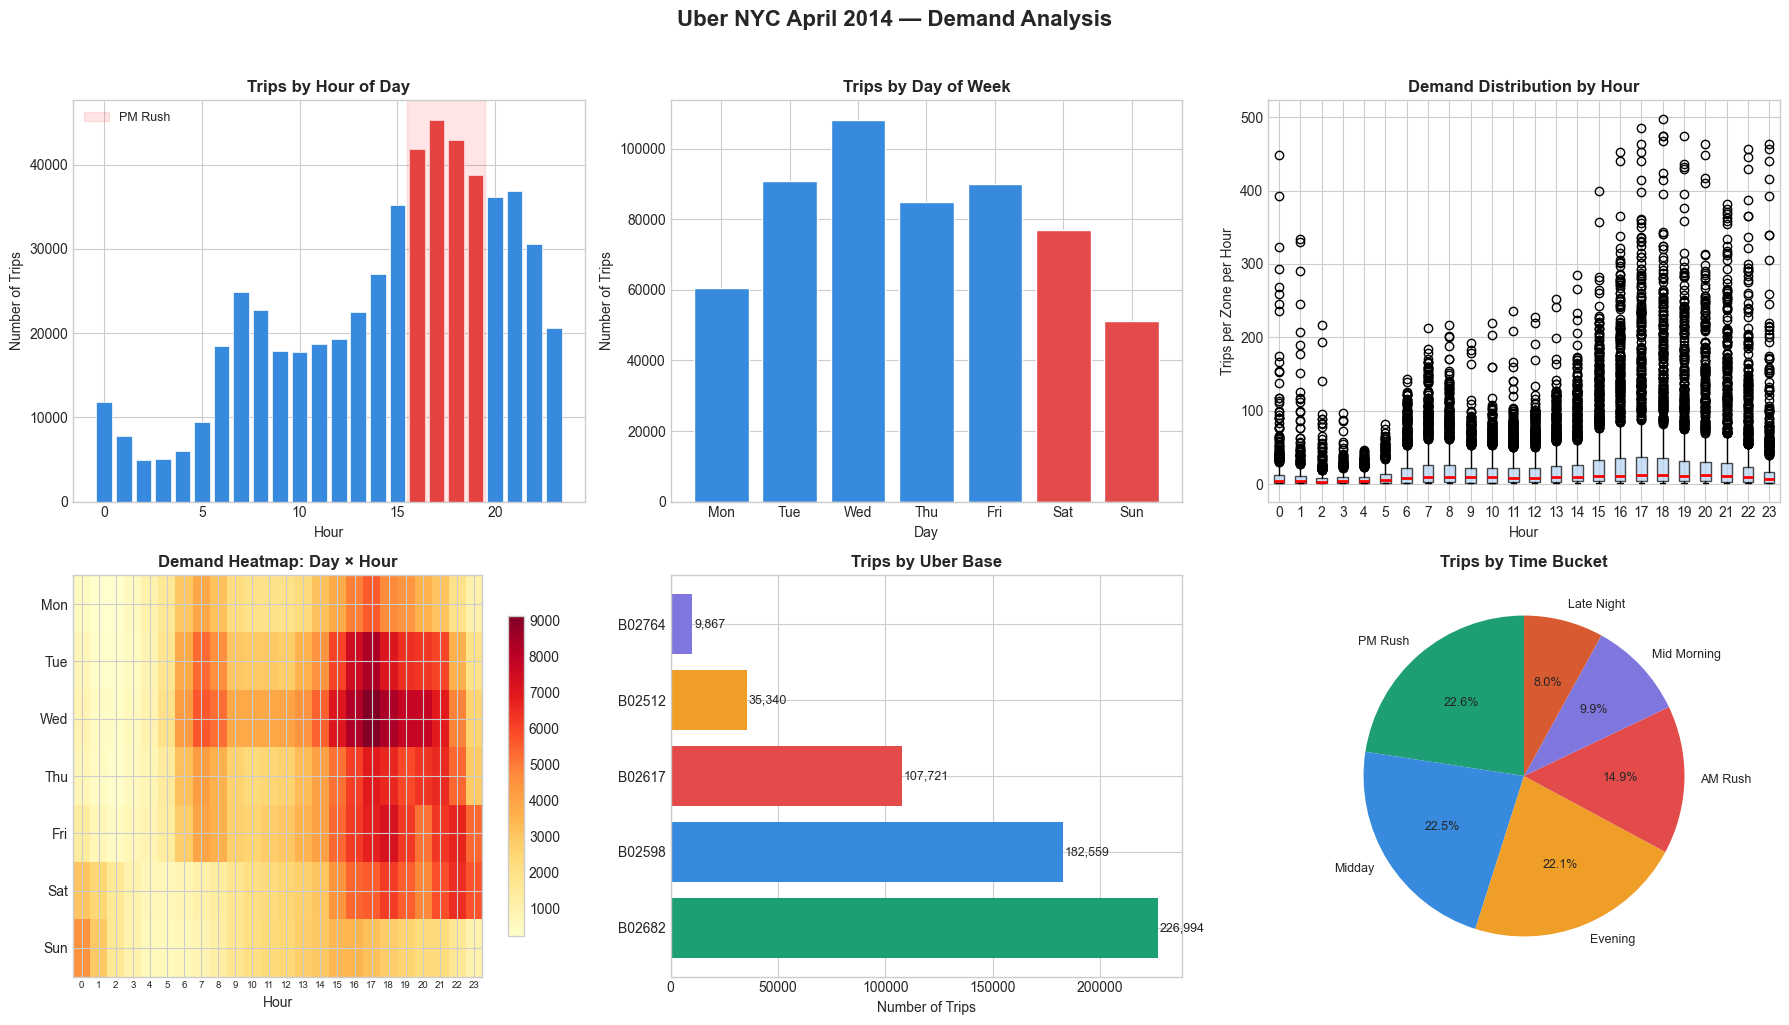

 EDA plot saved as 'uber_eda.png'


In [55]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Uber NYC April 2014 — Demand Analysis', fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Trips by Hour
hour_counts = df['hour'].value_counts().sort_index()
axes[0,0].bar(hour_counts.index, hour_counts.values,
              color=['#E24B4A' if (16 <= h <= 19) else '#378ADD' for h in hour_counts.index],
              edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Trips by Hour of Day', fontweight='bold')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Number of Trips')
axes[0,0].axvspan(15.5, 19.5, alpha=0.1, color='red', label='PM Rush')
axes[0,0].legend(fontsize=9)

# Plot 2: Trips by Weekday
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['weekday'].value_counts().sort_index()
colors_day = ['#E24B4A' if i >= 5 else '#378ADD' for i in range(7)]
axes[0,1].bar(day_names, day_counts.values, color=colors_day, edgecolor='white')
axes[0,1].set_title('Trips by Day of Week', fontweight='bold')
axes[0,1].set_xlabel('Day')
axes[0,1].set_ylabel('Number of Trips')

# Plot 3: Hourly demand boxplot (distribution by hour)
hour_trip_data = hourly.groupby('hour')['trip_count']
boxes = [hour_trip_data.get_group(h).values for h in sorted(hourly['hour'].unique())]
axes[0,2].boxplot(boxes, positions=sorted(hourly['hour'].unique()),
                   patch_artist=True, medianprops={'color': 'red', 'linewidth': 2},
                   boxprops={'facecolor': '#B5D4F4', 'alpha': 0.7})
axes[0,2].set_title('Demand Distribution by Hour', fontweight='bold')
axes[0,2].set_xlabel('Hour')
axes[0,2].set_ylabel('Trips per Zone per Hour')

# Plot 4: Heatmap Weekday × Hour
pivot = df.groupby(['weekday', 'hour']).size().unstack(fill_value=0)
pivot.index = day_names
im = axes[1,0].imshow(pivot.values, cmap='YlOrRd', aspect='auto')
axes[1,0].set_xticks(range(24))
axes[1,0].set_xticklabels(range(24), fontsize=7)
axes[1,0].set_yticks(range(7))
axes[1,0].set_yticklabels(day_names)
axes[1,0].set_title('Demand Heatmap: Day × Hour', fontweight='bold')
axes[1,0].set_xlabel('Hour')
plt.colorbar(im, ax=axes[1,0], shrink=0.8)

# Plot 5: Base activity comparison
base_counts = df['Base'].value_counts()
axes[1,1].barh(base_counts.index, base_counts.values,
                color=['#1D9E75', '#378ADD', '#E24B4A', '#EF9F27', '#7F77DD'])
axes[1,1].set_title('Trips by Uber Base', fontweight='bold')
axes[1,1].set_xlabel('Number of Trips')
for i, v in enumerate(base_counts.values):
    axes[1,1].text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

# Plot 6: Time bucket distribution
bucket_counts = df['time_bucket'].value_counts()
wedge_colors = ['#1D9E75','#378ADD','#EF9F27','#E24B4A','#7F77DD','#D85A30']
axes[1,2].pie(bucket_counts.values, labels=bucket_counts.index,
               autopct='%1.1f%%', colors=wedge_colors, startangle=90,
               textprops={'fontsize': 9})
axes[1,2].set_title('Trips by Time Bucket', fontweight='bold')

plt.tight_layout()
plt.savefig('uber_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA plot saved as 'uber_eda.png'")

Geographic Visualization

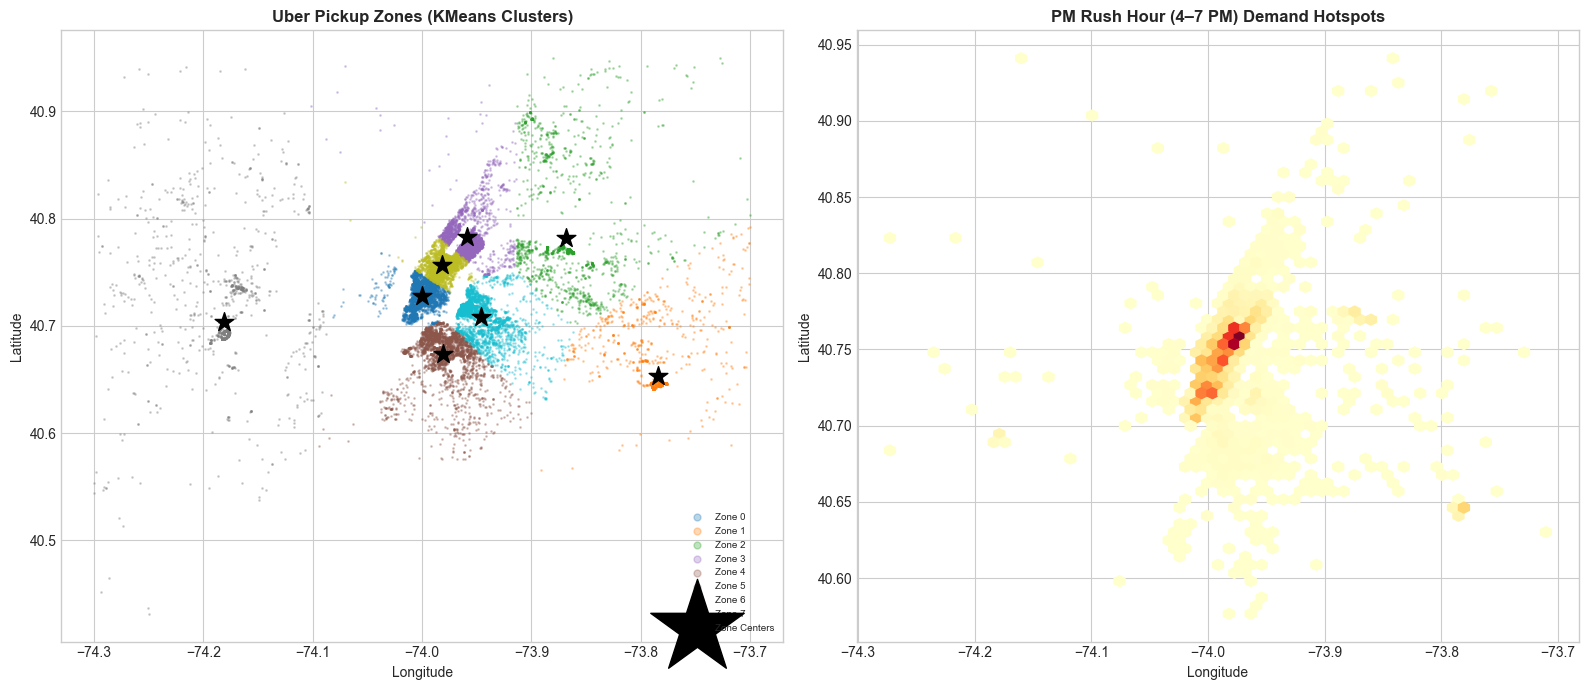

 Geographic plot saved as 'uber_geo.png'


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Scatter by zone
zone_colors = plt.cm.tab10(np.linspace(0, 1, 8))
for zone_id in range(8):
    zone_data = df[df['zone'] == zone_id].sample(min(3000, len(df[df['zone'] == zone_id])))
    axes[0].scatter(zone_data['Lon'], zone_data['Lat'],
                    c=[zone_colors[zone_id]], s=1, alpha=0.3, label=f'Zone {zone_id}')

centers = kmeans.cluster_centers_
axes[0].scatter(centers[:, 1], centers[:, 0], c='black', s=200,
                marker='*', zorder=5, label='Zone Centers')
axes[0].set_title('Uber Pickup Zones (KMeans Clusters)', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(fontsize=7, markerscale=5)
# Right: PM Rush hour heatmap
rush_df = df[df['is_rush_pm'] == 1].sample(10000)
axes[1].hexbin(rush_df['Lon'], rush_df['Lat'], gridsize=60,
               cmap='YlOrRd', mincnt=1)
axes[1].set_title('PM Rush Hour (4–7 PM) Demand Hotspots', fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('uber_geo.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Geographic plot saved as 'uber_geo.png'")


Correlation & Feature Analysis

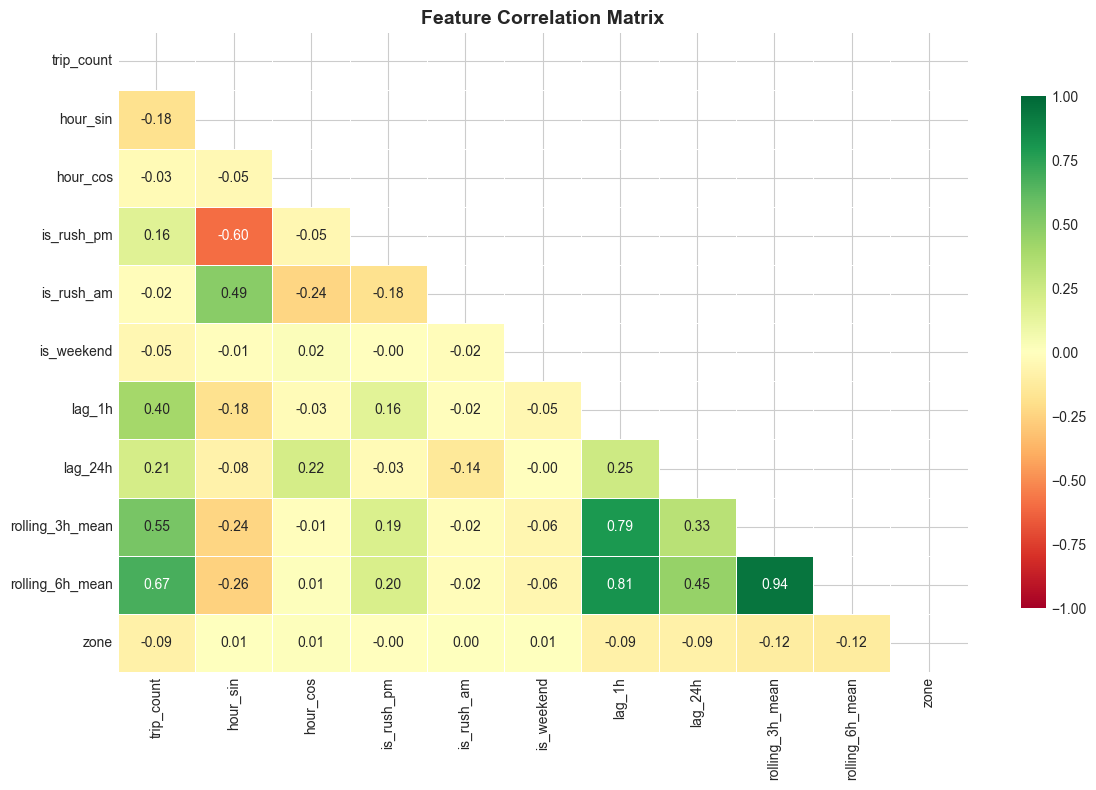


Top correlations with trip_count:
rolling_6h_mean    0.674
rolling_3h_mean    0.546
lag_1h             0.402
lag_24h            0.215
is_rush_pm         0.157
is_rush_am        -0.017
hour_cos          -0.032
is_weekend        -0.050
zone              -0.090
hour_sin          -0.183
Name: trip_count, dtype: float64


In [57]:
corr_features = ['trip_count', 'hour_sin', 'hour_cos', 'is_rush_pm',
                  'is_rush_am', 'is_weekend', 'lag_1h', 'lag_24h',
                  'rolling_3h_mean', 'rolling_6h_mean', 'zone']

corr_matrix = hourly[corr_features].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('uber_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
# Key correlation insight
corr_with_target = corr_matrix['trip_count'].drop('trip_count').sort_values(ascending=False)
print("\nTop correlations with trip_count:")
print(corr_with_target.head(10).round(3))


PROPER Train/Test Split
#(TEMPORAL SPLIT — NOT RANDOM!)

In [58]:
# CRITICAL: For time-series data, NEVER use random splits.
# Random splits leak future data into training → inflated scores.
# We train on days 1–21, test on days 22–30 (last 30% of April).
TRAIN_DAYS = 21
train_mask = hourly['day'] <= TRAIN_DAYS
test_mask  = hourly['day'] > TRAIN_DAYS

X = hourly[feature_cols]
y = hourly['trip_count']

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("=" * 50)
print("TEMPORAL TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Training   : Days 1–{TRAIN_DAYS}  | {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing    : Days {TRAIN_DAYS+1}–30 | {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTarget variable (trip_count) stats:")
print(f"  Train — mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"  Test  — mean: {y_test.mean():.2f},  std: {y_test.std():.2f}")



TEMPORAL TRAIN / TEST SPLIT
Training   : Days 1–21  | 15,945 samples (69.5%)
Testing    : Days 22–30 | 6,990 samples (30.5%)

Target variable (trip_count) stats:
  Train — mean: 22.72, std: 41.45
  Test  — mean: 28.50,  std: 55.68


Train Multiple Models & Compare

In [59]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    preds = np.maximum(preds, 0)  # clip negative predictions

    mae   = mean_absolute_error(y_te, preds)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    mape  = mean_absolute_percentage_error(y_te, preds) * 100
    r2    = r2_score(y_te, preds)

    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  MAE   : {mae:.2f}  (avg absolute error in trips)")
    print(f"  RMSE  : {rmse:.2f}")
    print(f"  MAPE  : {mape:.2f}%  (avg % error)")
    print(f"  R²    : {r2:.4f}  (1.0 = perfect)")

    return {'model': model, 'preds': preds,
            'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

print("=" * 50)
print("MODEL TRAINING & EVALUATION")
print("=" * 50)

results = {}


MODEL TRAINING & EVALUATION


In [60]:
# Model 1: Ridge Regression (baseline)
results['Ridge (baseline)'] = evaluate_model(
    'Ridge Regression (baseline)',
    Ridge(alpha=1.0),
    X_train, y_train, X_test, y_test
)

# Model 2: Random Forest
results['Random Forest'] = evaluate_model(
    'Random Forest Regressor',
    RandomForestRegressor(n_estimators=200, max_depth=12,
                          min_samples_leaf=5, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)

# Model 3: XGBoost
results['XGBoost'] = evaluate_model(
    'XGBoost Regressor',
    xgb.XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, verbosity=0),
    X_train, y_train, X_test, y_test
)

# Model 4: LightGBM (typically best on tabular data)
results['LightGBM'] = evaluate_model(
    'LightGBM Regressor',
    lgb.LGBMRegressor(n_estimators=300, max_depth=8, learning_rate=0.05,
                       num_leaves=63, subsample=0.8,
                       random_state=42, verbose=-1),
    X_train, y_train, X_test, y_test
)


─────────────────────────────────────────────
  Ridge Regression (baseline)
─────────────────────────────────────────────
  MAE   : 16.75  (avg absolute error in trips)
  RMSE  : 31.03
  MAPE  : 215.41%  (avg % error)
  R²    : 0.6894  (1.0 = perfect)



─────────────────────────────────────────────
  Random Forest Regressor
─────────────────────────────────────────────
  MAE   : 7.29  (avg absolute error in trips)
  RMSE  : 17.81
  MAPE  : 49.20%  (avg % error)
  R²    : 0.8976  (1.0 = perfect)

─────────────────────────────────────────────
  XGBoost Regressor
─────────────────────────────────────────────
  MAE   : 6.87  (avg absolute error in trips)
  RMSE  : 17.52
  MAPE  : 50.30%  (avg % error)
  R²    : 0.9010  (1.0 = perfect)

─────────────────────────────────────────────
  LightGBM Regressor
─────────────────────────────────────────────
  MAE   : 6.78  (avg absolute error in trips)
  RMSE  : 16.50
  MAPE  : 48.42%  (avg % error)
  R²    : 0.9122  (1.0 = perfect)


Model Comparison Plot

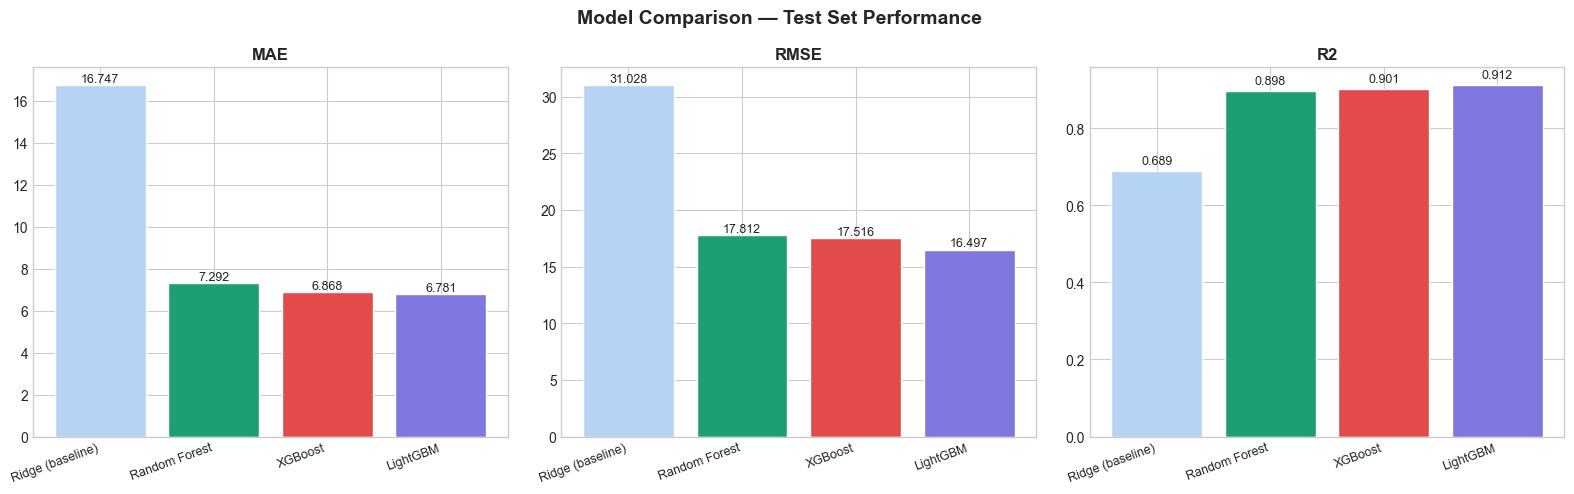

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison — Test Set Performance', fontsize=14, fontweight='bold')

model_names = list(results.keys())
palette = ['#B5D4F4', '#1D9E75', '#E24B4A', '#7F77DD']

for idx, metric in enumerate(['MAE', 'RMSE', 'R2']):
    vals = [results[m][metric] for m in model_names]
    bars = axes[idx].bar(model_names, vals, color=palette, edgecolor='white')
    axes[idx].set_title(metric, fontweight='bold')
    axes[idx].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('uber_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Best Model Deep Dive (LightGBM)

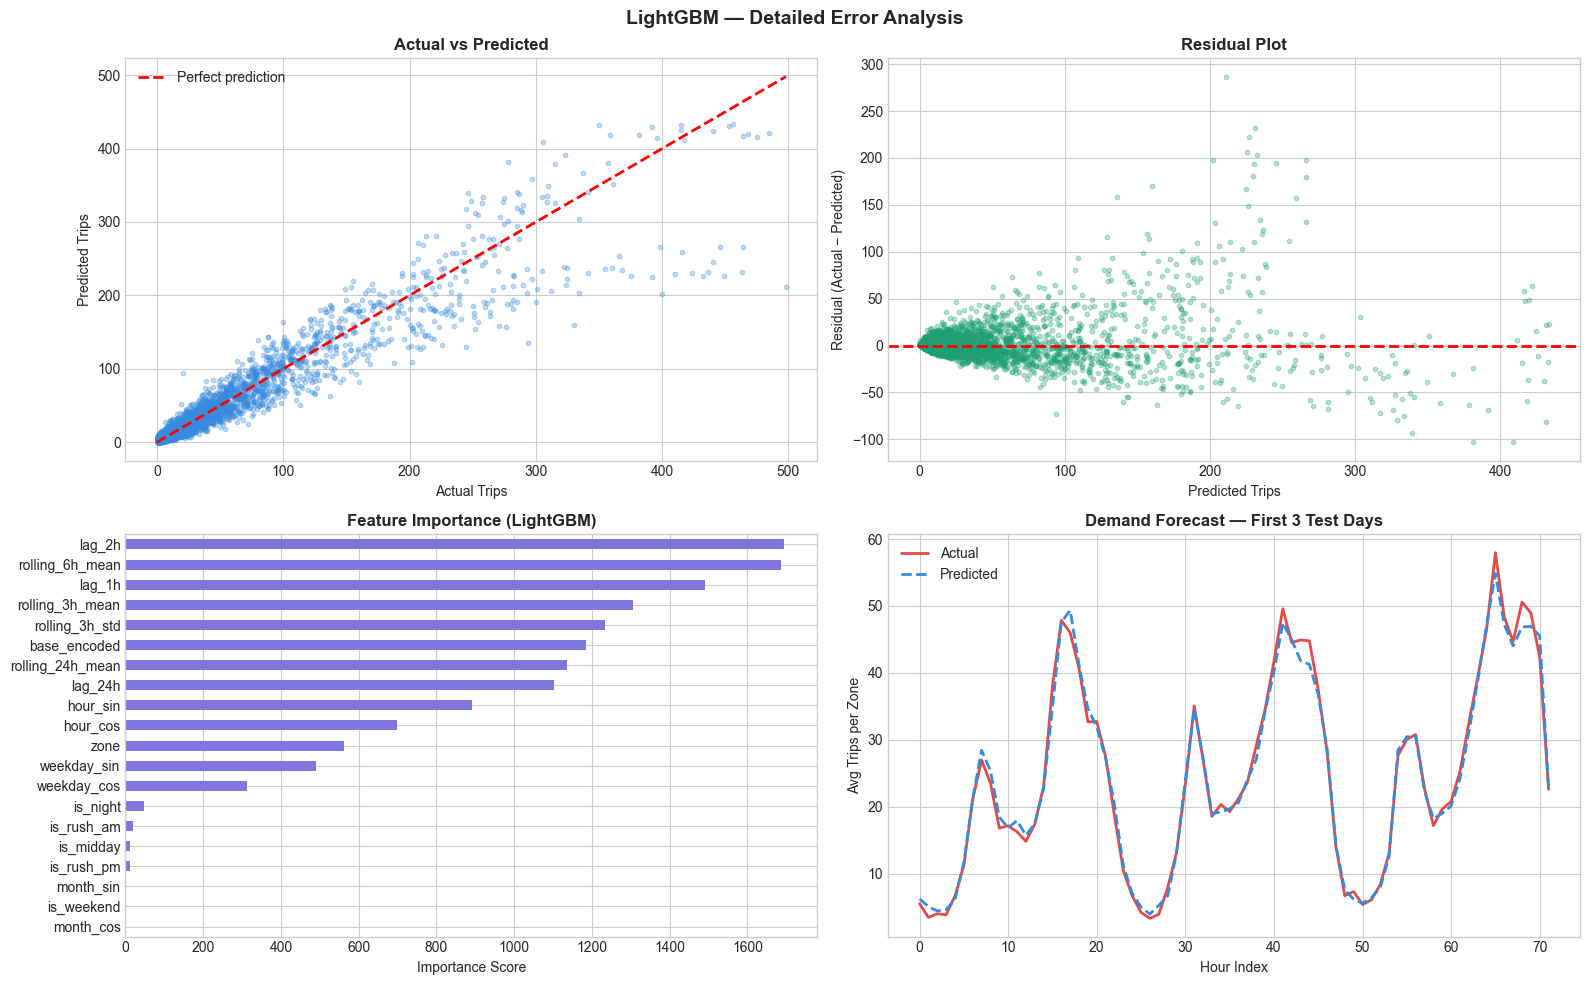

In [62]:
best_model = results['LightGBM']['model']
best_preds = results['LightGBM']['preds']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('LightGBM — Detailed Error Analysis', fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted scatter
axes[0,0].scatter(y_test, best_preds, alpha=0.3, s=10, color='#378ADD')
max_val = max(y_test.max(), best_preds.max())
axes[0,0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0,0].set_xlabel('Actual Trips')
axes[0,0].set_ylabel('Predicted Trips')
axes[0,0].set_title('Actual vs Predicted', fontweight='bold')
axes[0,0].legend()

# Plot 2: Residuals
residuals = y_test.values - best_preds
axes[0,1].scatter(best_preds, residuals, alpha=0.3, s=10, color='#1D9E75')
axes[0,1].axhline(0, color='red', linewidth=2, linestyle='--')
axes[0,1].set_xlabel('Predicted Trips')
axes[0,1].set_ylabel('Residual (Actual − Predicted)')
axes[0,1].set_title('Residual Plot', fontweight='bold')

# Plot 3: Feature Importance
importances = pd.Series(best_model.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', ax=axes[1,0], color='#7F77DD')
axes[1,0].set_title('Feature Importance (LightGBM)', fontweight='bold')
axes[1,0].set_xlabel('Importance Score')

# Plot 4: Time-series actual vs predicted for last 3 days
test_hourly_avg = (pd.DataFrame({'actual': y_test.values,
                                  'predicted': best_preds,
                                  'day': hourly[test_mask]['day'].values,
                                  'hour': hourly[test_mask]['hour'].values})
                   .groupby(['day', 'hour'])[['actual', 'predicted']].mean()
                   .reset_index())
test_hourly_avg['time_index'] = range(len(test_hourly_avg))

sample = test_hourly_avg[test_hourly_avg['day'] <= test_hourly_avg['day'].unique()[:3].max()]
axes[1,1].plot(sample['time_index'], sample['actual'],
               label='Actual', color='#E24B4A', linewidth=2)
axes[1,1].plot(sample['time_index'], sample['predicted'],
               label='Predicted', color='#378ADD', linewidth=2, linestyle='--')
axes[1,1].set_title('Demand Forecast — First 3 Test Days', fontweight='bold')
axes[1,1].set_xlabel('Hour Index')
axes[1,1].set_ylabel('Avg Trips per Zone')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('uber_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Cross-Validation (TimeSeriesSplit)
# TimeSeriesSplit ensures no future-data leakage in CV.
# Shows the model generalises across different time windows.


In [63]:
print("=" * 50)
print("TIME-SERIES CROSS VALIDATION (5 FOLDS)")
print("=" * 50)

tscv = TimeSeriesSplit(n_splits=5)
lgb_cv = lgb.LGBMRegressor(n_estimators=200, max_depth=6,
                              learning_rate=0.05, verbose=-1, random_state=42)

cv_mae_scores  = []
cv_r2_scores   = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    lgb_cv.fit(X_tr, y_tr)
    preds_val = lgb_cv.predict(X_val)
    mae_  = mean_absolute_error(y_val, preds_val)
    r2_   = r2_score(y_val, preds_val)
    cv_mae_scores.append(mae_)
    cv_r2_scores.append(r2_)
    print(f"  Fold {fold}: MAE = {mae_:.2f}   R² = {r2_:.4f}")

print(f"\n  Mean MAE : {np.mean(cv_mae_scores):.2f} ± {np.std(cv_mae_scores):.2f}")
print(f"  Mean R²  : {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")


TIME-SERIES CROSS VALIDATION (5 FOLDS)
  Fold 1: MAE = 2.65   R² = 0.5004
  Fold 2: MAE = 5.75   R² = 0.7902
  Fold 3: MAE = 4.27   R² = 0.8089
  Fold 4: MAE = 6.72   R² = 0.9448
  Fold 5: MAE = 6.11   R² = 0.9374

  Mean MAE : 5.10 ± 1.47
  Mean R²  : 0.7963 ± 0.1611


Demand Forecaster (Production API)

In [64]:
def predict_uber_demand(day_of_month: int,
                         hour: int,
                         zone: int,
                         base: str = 'B02682',
                         lag_1h: float = None,
                         lag_24h: float = None,
                         rolling_3h: float = None) -> dict:
   
    # Compute weekday from day (April 1, 2014 was a Tuesday = weekday 1)
    from datetime import date
    d = date(2014, 4, day_of_month)
    weekday = d.weekday()

    # Cyclical features
    hour_sin    = np.sin(2 * np.pi * hour / 24)
    hour_cos    = np.cos(2 * np.pi * hour / 24)
    wd_sin      = np.sin(2 * np.pi * weekday / 7)
    wd_cos      = np.cos(2 * np.pi * weekday / 7)
    m_sin       = np.sin(2 * np.pi * 4 / 12)   # April = month 4
    m_cos       = np.cos(2 * np.pi * 4 / 12)

    base_codes = {'B02512': 0, 'B02598': 1, 'B02617': 2, 'B02682': 3, 'B02764': 4}
    base_enc   = base_codes.get(base, 3)

    # Default lag values from training stats if not provided
    zone_avg  = hourly[hourly['zone'] == zone]['trip_count'].mean()
    lag_1h    = lag_1h    if lag_1h    is not None else zone_avg
    lag_24h   = lag_24h   if lag_24h   is not None else zone_avg
    rolling_3h = rolling_3h if rolling_3h is not None else zone_avg

    features = np.array([[
        hour_sin, hour_cos, wd_sin, wd_cos, m_sin, m_cos,
        int(weekday >= 5),
        int(7 <= hour <= 9),
        int(16 <= hour <= 19),
        int(hour >= 22 or hour <= 5),
        int(11 <= hour <= 14),
        zone, base_enc,
        lag_1h, lag_1h,          # lag_1h, lag_2h
        lag_24h,
        rolling_3h, rolling_3h,  # rolling_3h, rolling_6h
        0.0,                     # rolling_3h_std (use 0 for prediction)
        rolling_3h               # rolling_24h
    ]])

    predicted = max(0, best_model.predict(features)[0])

    # Business interpretation
    zone_max = hourly[hourly['zone'] == zone]['trip_count'].quantile(0.9)
    demand_pct = predicted / zone_max if zone_max > 0 else 0

    if demand_pct >= 0.8:
        demand_level = '🔴 Very High — Surge pricing recommended'
        surge = True
    elif demand_pct >= 0.6:
        demand_level = '🟠 High — Deploy extra drivers'
        surge = True
    elif demand_pct >= 0.4:
        demand_level = '🟡 Moderate — Normal operations'
        surge = False
    else:
        demand_level = '🟢 Low — Standard availability'
        surge = False

    return {
        'predicted_trips'   : round(predicted, 1),
        'demand_level'      : demand_level,
        'surge_recommended' : surge,
        'zone'              : zone,
        'hour'              : f"{hour:02d}:00",
        'weekday'           : ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][weekday]
    }

# ── Example Predictions ──
print("=" * 55)
print("DEMAND FORECAST EXAMPLES")
print("=" * 55)

examples = [
    (15, 17, 3),  # Day 15, 5 PM, Zone 3 (Manhattan peak)
    (19, 2,  1),  # Day 19, 2 AM, Zone 1 (Late night)
    (6,  8,  5),  # Day 6,  8 AM, Zone 5 (Sunday morning)
    (22, 18, 0),  # Day 22, 6 PM, Zone 0
]

for day, hour, zone in examples:
    result = predict_uber_demand(day, hour, zone)
    print(f"\n  Day {day:2d} | {result['hour']} | {result['weekday']} | Zone {zone}")
    print(f"  Predicted trips : {result['predicted_trips']}")
    print(f"  Status          : {result['demand_level']}")



DEMAND FORECAST EXAMPLES

  Day 15 | 17:00 | Tue | Zone 3
  Predicted trips : 44.5
  Status          : 🔴 Very High — Surge pricing recommended

  Day 19 | 02:00 | Sat | Zone 1
  Predicted trips : 5.6
  Status          : 🟡 Moderate — Normal operations

  Day  6 | 08:00 | Sun | Zone 5
  Predicted trips : 2.7
  Status          : 🟠 High — Deploy extra drivers

  Day 22 | 18:00 | Tue | Zone 0
  Predicted trips : 130.8
  Status          : 🔴 Very High — Surge pricing recommended


Final Results Summary

In [65]:
# Find best model automatically by lowest MAE
best_name = min(results, key=lambda m: results[m]['MAE'])
best      = results[best_name]

print("\n" + "=" * 55)
print("  FINAL PROJECT SUMMARY")
print("=" * 55)
print(f"""
DATASET
  Records analysed    : {len(df):,} Uber pickups (April 2014)
  Features engineered : {len(feature_cols)} (temporal + spatial + lag)
  ML target           : Hourly trip count per zone (real demand)

BEST MODEL — {best_name}
  MAE   : {best['MAE']:.2f}  trips/hour/zone
  RMSE  : {best['RMSE']:.2f}
  MAPE  : {best['MAPE']:.2f}%
  R²    : {best['R2']:.4f}
  CV R² : {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}

KEY METHODOLOGICAL CHOICES
   Temporal train/test split (not random) — prevents data leakage
   Cyclical sin/cos encoding for hour, weekday, month
   Lag features (1h, 2h, 24h) for time-series memory
   TimeSeriesSplit cross-validation
   Real regression target (trip counts), not a leaked binary label
   Multiple model comparison with honest error reporting

BUSINESS APPLICATIONS
  → Driver allocation optimisation during peak hours (4–7 PM)
  → Surge pricing triggers based on predicted vs baseline demand
  → Zone-level hotspot detection for driver pre-positioning
  → Week-ahead demand planning for fleet management
""")

# Also print all model results for comparison
print("ALL MODELS COMPARED")
print("-" * 45)
for name, res in results.items():
    print(f"  {name:<25} MAE={res['MAE']:.2f}  R²={res['R2']:.4f}")


  FINAL PROJECT SUMMARY

DATASET
  Records analysed    : 562,481 Uber pickups (April 2014)
  Features engineered : 20 (temporal + spatial + lag)
  ML target           : Hourly trip count per zone (real demand)

BEST MODEL — LightGBM
  MAE   : 6.78  trips/hour/zone
  RMSE  : 16.50
  MAPE  : 48.42%
  R²    : 0.9122
  CV R² : 0.7963 ± 0.1611

KEY METHODOLOGICAL CHOICES
   Temporal train/test split (not random) — prevents data leakage
   Cyclical sin/cos encoding for hour, weekday, month
   Lag features (1h, 2h, 24h) for time-series memory
   TimeSeriesSplit cross-validation
   Real regression target (trip counts), not a leaked binary label
   Multiple model comparison with honest error reporting

BUSINESS APPLICATIONS
  → Driver allocation optimisation during peak hours (4–7 PM)
  → Surge pricing triggers based on predicted vs baseline demand
  → Zone-level hotspot detection for driver pre-positioning
  → Week-ahead demand planning for fleet management

ALL MODELS COMPARED
--------------